# 04 — Changing properties on the fly

Any target, instrument or detector property can be changed **without rebuilding** the target,
with `change_properties()`. The detector configuration is kept until you change it (or call
`setup_to_snr()` again).

Typical use: you set up the observation for the *expected* target, and see what you get if the
target is actually different.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. Set up for the expected target...

In [2]:
snia = slicersim.LazuliSupernova(redshift=1.0, x1=0, c=0, phase=0)
snr_range = dict(lbda_range=[4000, 7000], frame="rest")

config, snr = snia.setup_to_snr(10, **snr_range)
print(config, f"SNR={snr:.1f}", f"{snia.get_exposure_time()/3600:.2f} h")

{'nmd': (64, 8, 0), 'nramps': 2} SNR=8.9 0.80 h


## 2. ...and change the target

`change_properties()` accepts any mutable parameter (short names are fine when unambiguous).
Let us see how the SNR changes if the SN is at a different redshift, with the same exposure.

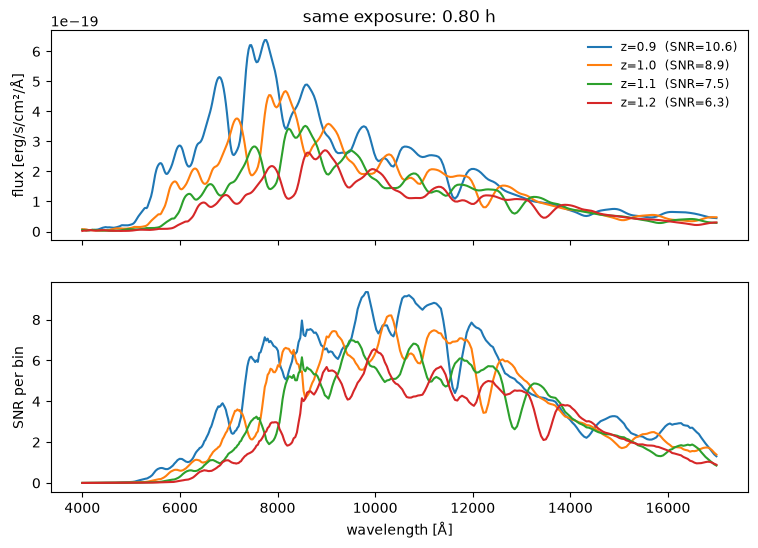

In [3]:
fig, (ax, ax_snr) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for redshift in [0.9, 1.0, 1.1, 1.2]:
    snia.change_properties(redshift=redshift)
    lbda, flux, variance = snia.get_spectrum(unit="flambda", incl_error=False)
    snr = snia.get_band_snr(**snr_range)
    ax.plot(lbda, flux, label=f"z={redshift}  (SNR={snr:.1f})")
    ax_snr.plot(lbda, flux / np.sqrt(variance))

ax.set(ylabel="flux [erg/s/cm²/Å]", title=f"same exposure: {snia.get_exposure_time()/3600:.2f} h")
ax_snr.set(xlabel="wavelength [Å]", ylabel="SNR per bin")
ax.legend(frameon=False, fontsize="small")
snia.change_properties(redshift=1.0)  # back to the expected redshift

Same for the phase: the SN fades after maximum light.

In [4]:
for phase in [-10, 0, 10, 20]:
    snia.change_properties(phase=phase)
    print(f"phase={phase:+3d} d: SNR={snia.get_band_snr(**snr_range):.1f}")
snia.change_properties(phase=0)

phase=-10 d: SNR=7.8


phase= +0 d: SNR=8.9


phase=+10 d: SNR=8.3


phase=+20 d: SNR=6.4


***
## 3. Change the detector

Detector properties can be changed the same way. For instance, a degraded detector at the end
of the mission (higher dark current, RON and ROIC glow):

In [5]:
print("current:", snia.get_properties(["dark", "ron", "roic_glow"]))
print(f"SNR={snia.get_band_snr(**snr_range):.1f}")

snia.change_properties(dark=0.01, ron=20, roic_glow=0.01)
print("degraded:", snia.get_properties(["dark", "ron", "roic_glow"]))
print(f"SNR={snia.get_band_snr(**snr_range):.1f}")

current: {'dark': 0.0028, 'ron': 12.0, 'roic_glow': 0.003}


SNR=8.9
degraded: {'dark': 0.01, 'ron': 20, 'roic_glow': 0.01}


SNR=5.7


The Lazuli end-of-life (EOL) instrument configuration, which also includes a degraded
throughput, is available with `change_configuration("eol")` (and `"cbe"`, current best
estimate, the default). How much longer must we expose to recover SNR=10?

In [6]:
import warnings
warnings.filterwarnings("ignore", message=".*not.*mutable")  # config keys that cannot change are skipped

for configuration in ["cbe", "eol"]:
    snia.change_configuration(configuration)
    _ = snia.setup_to_snr(10, **snr_range)
    print(f"{configuration}: {snia.get_readout_config()}  ->  {snia.get_exposure_time()/3600:.2f} h")

cbe: {'nmd': (64, 8, 0), 'nramps': 2}  ->  0.80 h


eol: {'nmd': (64, 8, 0), 'nramps': 8}  ->  3.22 h


All mutable parameters (target, background, telescope, spectrograph, detector, extraction):

In [7]:
print(snia.simulation.mutable_parameters)

['pointsource.phase', 'pointsource.abmag', 'pointsource.redshift', 'pointsource.MBmax', 'pointsource.source', 'pointsource.cosmo', 'pointsource.x1', 'pointsource.c', 'pointsource.alpha', 'pointsource.beta', 'pointsource.position', 'background.scale', 'background.model', 'temperature', 'emissivity', 'diameter_ext', 'diameter_int', 'surface', 'dispersion_resolution', 'spotsize', 'dispersion_scale', 'which_throughput', 'xdisp_sigma_spectral', 'xdisp_sigma', 'psf_sigma_spectral', 'guiding_sigma', 'spatial_scale', 'spatial_shape', 'spx_scale', 'spx_shape', 'telescope.temperature', 'telescope.emissivity', 'telescope.diameter_ext', 'telescope.diameter_int', 'telescope.surface', 'optics.temperature', 'optics.emissivity', 'optics.nelements', 'throughput.noptics', 'detector.ngroup', 'detector.nframe_per_group', 'detector.nmd', 'detector.tframe', 'detector.max_group', 'detector.ron', 'detector.gain', 'detector.qe', 'detector.dark', 'detector.saturation', 'detector.variance_model', 'detector.ron_f

***
## 4. Changing the magnitude of any target

Back to the toy galaxy of notebook 02. For a `LazuliTarget` (or `LazuliCalSpec`,
`LazuliBlackBody`, ...), `mag` and `band` are properties you can change.

In [8]:
def emission_line_galaxy(lbda, redshift=1.4, ew=[60, 20, 30, 90, 150, 50], sigma=4.):
    """ Toy star-forming galaxy: power-law continuum + Gaussian emission lines.

    lbda in Å (observer frame); ew are the rest-frame equivalent widths [Å] of
    [OII], Hβ, [OIII]4959, [OIII]5007, Hα, [NII]6583; sigma the rest-frame line width [Å].
    """
    lines = [3727, 4861, 4959, 5007, 6563, 6583]  # rest-frame [Å]
    lbda_rest = lbda / (1 + redshift)
    continuum = (lbda_rest / 5000) ** -1.5
    spectrum = continuum.copy()
    for line, ew_ in zip(lines, ew):
        profile = np.exp(-0.5 * ((lbda_rest - line) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)
        spectrum += ew_ * continuum * profile
    return spectrum

In [9]:
lbda_in = np.arange(3_000, 20_000, 1.0)
galaxy = slicersim.LazuliTarget(lbda_in, emission_line_galaxy(lbda_in), mag=24, band="sdssi")
_ = galaxy.setup_to_snr(5, lbda_range=[10_000, 12_000], frame="obs")
print(galaxy.get_readout_config(), f"{galaxy.get_exposure_time()/3600:.1f} h")

{'nmd': (31, 8, 0), 'nramps': 1} 0.2 h


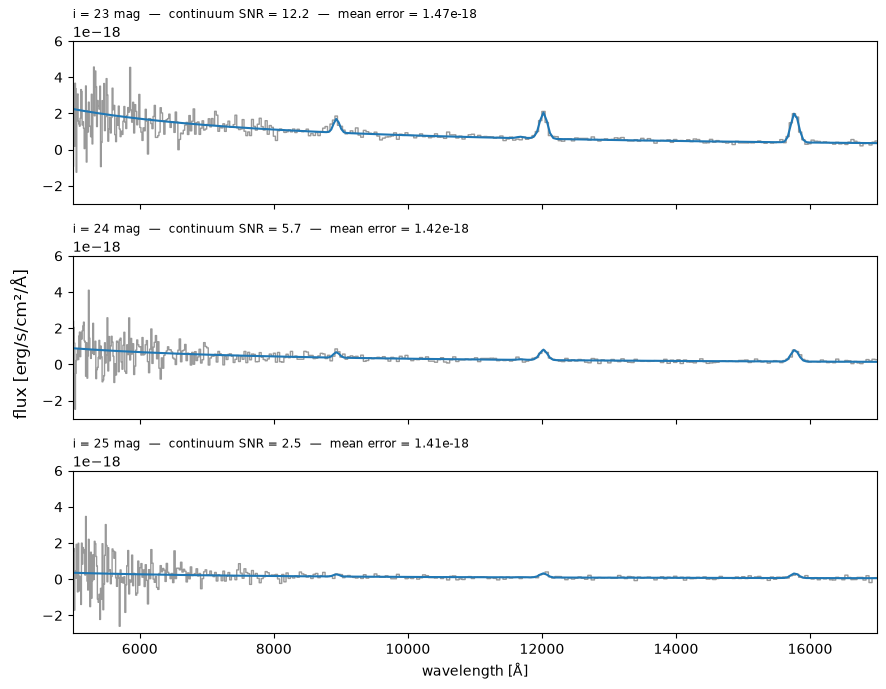

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, mag in zip(axes, [23, 24, 25]):
    galaxy.change_properties(mag=mag)
    lbda, flux, variance = galaxy.get_spectrum(unit="flambda")
    _, flux_true, _ = galaxy.get_spectrum(unit="flambda", incl_error=False)
    snr = galaxy.get_band_snr([10_000, 12_000], frame="obs")
    ax.plot(lbda, flux, color="0.6", lw=1, ds="steps-mid")
    ax.plot(lbda, flux_true, color="C0")
    ax.set_ylim(-3e-18, 6e-18)
    ax.set_title(f"i = {mag} mag  —  continuum SNR = {snr:.1f}  —  mean error = {np.mean(np.sqrt(variance)):.2e}",
                 loc="left", fontsize="small")

axes[-1].set(xlabel="wavelength [Å]", xlim=(5000, 17000))
fig.supylabel("flux [erg/s/cm²/Å]")
fig.tight_layout()

The error barely changes with the magnitude: the noise is dominated by the detector, not by
the photon noise of the source (see notebook 05). The SNR therefore scales almost linearly
with the flux.

***
## Recap

- `target.change_properties(**kwargs)` changes any mutable parameter on the fly:
  target (`redshift`, `phase`, `mag`...), detector (`dark`, `ron`...), etc.
- The detector configuration is **not** re-optimised: call `setup_to_snr()` again for that.
- `change_configuration("eol" | "cbe")` switches the instrument configuration.

**Next:** [05 — Origin of the variance](05_variance_budget.ipynb)